## P5 import package

In [45]:
import sqlite3
import pandas as pd
import numpy as np
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer
print("Yellowbrick importé avec succès !")
from sklearn.neighbors import NearestNeighbors

Yellowbrick importé avec succès !


## SetUp message display

In [46]:
def display_info(title = "",titleTag="h2",tag="div",pTag="p",message="Params allowed: title,tag,message,color",bgd="#96d6ee", styleClass="alert alert-block alert-info", fontsize="" , color="black"):
    if (title!=""):
        display(HTML(f"""<{titleTag} style='color:{color};font-size:{fontsize}'>{title}</{titleTag}>"""))
    else:
        display(HTML(f"""
                     <{tag} style='background:{bgd}; padding-top:5px; padding-bottom:5px; padding-left:10px;' class='{styleClass}'><{pTag} style='color:{color}; font-size:{fontsize}'>{message}</{pTag}></{tag}>
"""))

In [47]:
display_info(title="Connection to the olist db and display list of the tables available",color="red")
conn = sqlite3.connect('./datas/olist.db')
query = "SELECT name FROM sqlite_master WHERE type='table';"
tables = pd.read_sql_query(query,conn)
print(tables)

            name
0      customers
1         geoloc
2    order_items
3    order_pymts
4  order_reviews
5         orders
6       products
7        sellers
8    translation


In [48]:
display_info(title="Creation RFM Features as (Recency, Frequency, Monetary)",color="red")
display_info(message="""Recency : Dernière commande effectuée par le client (par rapport à une date de référence).
</br>Frequency : Nombre de commandes passées par le client.
</br>Monetary : Montant total dépensé par le client.""")

recency_query="""
WITH RealOrder AS (
    SELECT *
    FROM orders
    WHERE order_status <> 'canceled'
),
LastcustomerOrder AS (
    SELECT customer_id,
        MAX(order_purchase_timestamp) AS last_order_date
    FROM RealOrder
    GROUP BY customer_id
),
FinalSelection AS (
    SELECT ro.*,
        lco.last_order_date
    FROM RealORder ro
        INNER JOIN LastcustomerOrder lco ON ro.customer_id = lco.customer_id
        AND ro.order_purchase_timestamp = lco.last_order_date
)
SELECT 
    customer_id
FROM FinalSelection
ORDER BY customer_id,
    order_id DESC;
"""
frequency_query = """
WITH RealOrder AS (
    SELECT *
    FROM orders
    WHERE order_status <> 'canceled'
),
NbOrder AS (
    SELECT customer_id,
        COUNT (order_id) AS order_count
    FROM RealOrder
    GROUP BY customer_id
)
SELECT *
FROM NbOrder
ORDER BY order_count DESC;
"""
monetary_query = """
SELECT 
    c.customer_id,
    SUM(oi.price * oi.order_item_id) AS monetary
FROM customers c
LEFT JOIN orders o
    ON c.customer_id = o.customer_id
LEFT JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY c.customer_id;
"""

In [49]:
recency = pd.read_sql_query(recency_query, conn)
frequency = pd.read_sql_query(frequency_query, conn)
monetary = pd.read_sql_query(monetary_query, conn)
rfm = recency.merge(frequency, on='customer_id').merge(monetary, on='customer_id')


In [50]:
print(rfm.head())

                        customer_id  order_count  monetary
0  00012a2ce6f8dcda20d059ce98491703            1     89.80
1  000161a058600d5901f007fab4c27140            1     54.90
2  0001fd6190edaaf884bcaf3d49edf079            1    179.99
3  0002414f95344307404f0ace7a26f1d5            1    149.90
4  000379cdec625522490c315e70c7a9fb            1     93.00


In [51]:
display_info(title="Aggrégaion des tables",color="red")
display_info(message="""On créé des requetes dynamique pour pouvoir faire les agrégation</br>
             - Requete de recuperation de tuple dans une table</br>
             """, color="black")


In [52]:
def dynQuery(columns, table):
    query = f"""
    SELECT {columns}
    FROM {table}
    """
    return query

In [53]:
## Fonction d'exectution des requetes et retourne un df avec le resultat
def displayQueryRes(query):
    df = pd.read_sql_query(query,conn)
    return df

In [54]:
query = """
WITH temp_order AS (
SELECT * 
FROM orders
),
temp_order_with_customers AS (
SELECT
    t.*,
    c.customer_unique_id,
    c.customer_zip_code_prefix AS Customer_zip_code,
    c.customer_city,
    c.customer_state
FROM
    temp_order t
LEFT JOIN customers c
    ON t.customer_id = c.customer_id
),
temp_order_with_reviews AS (
SELECT
    t.*,
    r.review_score,
    r.review_comment_title,
    r.review_comment_message,
    r.review_creation_date,
    r.review_answer_timestamp
FROM
    temp_order_with_customers t
LEFT JOIN order_reviews r
    ON t.order_id = r.order_id
),
temp_order_with_pymts AS (
SELECT
    t.*,
    p.payment_sequential,
    p.payment_value,
    p.payment_installments
FROM
    temp_order_with_reviews t
LEFT JOIN order_pymts p
    ON t.order_id = p.order_id
),
temp_order_with_items AS (
SELECT
    t.*,
    i.product_id,
    i.seller_id,
    i.price,
    i.freight_value,
    i.shipping_limit_date
FROM 
    temp_order_with_pymts t
LEFT JOIN order_items i
    ON t.order_id = i.order_id
),
temp_order_with_products AS (
SELECT
    t.*,
    p.product_category_name,
    p.product_length_cm,
    p.product_height_cm,
    p.product_width_cm,
    p.product_weight_g
FROM 
    temp_order_with_items t
LEFT JOIN products p 
    ON t.product_id = p.product_id
),
temp_order_with_seller AS (
SELECT
    t.*,
    s.seller_zip_code_prefix AS Seller_zip_code
FROM temp_order_with_products t
LEFT JOIN sellers s
    ON t.seller_id = s.seller_id
)
SELECT *
FROM temp_order_with_seller;
"""

In [55]:
df = displayQueryRes(query)

In [56]:
df.head()

,index,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,...,seller_id,price,freight_value,shipping_limit_date,product_category_name,product_length_cm,product_height_cm,product_width_cm,product_weight_g,Seller_zip_code
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,...,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,2017-10-06 11:07:15,utilidades_domesticas,19.0,8.0,13.0,500.0,9350.0
1,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,...,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,2017-10-06 11:07:15,utilidades_domesticas,19.0,8.0,13.0,500.0,9350.0
2,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,...,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,8.72,2017-10-06 11:07:15,utilidades_domesticas,19.0,8.0,13.0,500.0,9350.0
3,1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,...,289cdb325fb7e7f891c38608bf9e0962,118.70,22.76,2018-07-30 03:24:27,perfumaria,19.0,13.0,19.0,400.0,31570.0
4,2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,...,4869f7a5dfa277a7dca6462dcf3b52b2,159.90,19.22,2018-08-13 08:55:23,automotivo,24.0,19.0,21.0,420.0,14840.0


In [57]:
display_info(message="""Types de données du dataset:""",color='black')
df.dtypes

index                              int64
order_id                          object
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
customer_unique_id                object
Customer_zip_code                  int64
customer_city                     object
customer_state                    object
review_score                     float64
review_comment_title              object
review_comment_message            object
review_creation_date              object
review_answer_timestamp           object
payment_sequential               float64
payment_value                    float64
payment_installments             float64
product_id                        object
seller_id                         object
price                            float64
freight_value   

In [58]:
display_info(message="""Pourcentage des valeurs manquantes du dataset  :""",color='black')
((df.isna().sum() / df.shape[0])*100).sort_values(ascending=False)

review_comment_title             88.258647
review_comment_message           57.827988
order_delivered_customer_date     2.871339
product_category_name             2.133571
order_delivered_carrier_date      1.750837
review_score                      0.836810
review_answer_timestamp           0.836810
review_creation_date              0.836810
product_length_cm                 0.715946
product_height_cm                 0.715946
product_width_cm                  0.715946
product_weight_g                  0.715946
shipping_limit_date               0.699160
freight_value                     0.699160
price                             0.699160
seller_id                         0.699160
product_id                        0.699160
Seller_zip_code                   0.699160
order_approved_at                 0.148561
payment_sequential                0.002518
payment_value                     0.002518
payment_installments              0.002518
order_id                          0.000000
customer_st

In [59]:
display_info(title="""Calcul des métrique""",color='red')
display_info(message="""On calcul la recency""",color='black')
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
recency = df.groupby('customer_unique_id')['order_purchase_timestamp'].max()
recency = (pd.Timestamp.now() - recency).dt.days
print("Nombre de valeurs calculées", recency.count())
display_info(message="""On calcul la frequency""",color='black')
frequency = df.groupby('customer_unique_id')['order_id'].nunique()
print("Nombre de valeurs calculées", frequency.count())
display_info(message="""On calcul la monetary""",color='black')
monetary = df.groupby('customer_unique_id')['price'].sum()
print("Nombre de valeurs calculées", monetary.count())

rfm = pd.DataFrame({'Recency': recency, 'Frequency':frequency, 'Monetary': monetary})
display(rfm)

Nombre de valeurs calculées 96096


Nombre de valeurs calculées 96096


Nombre de valeurs calculées 96096


,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,2419,1,129.90
0000b849f77a49e4a4ce2b2a4ca5be3f,2422,1,18.90
0000f46a3911fa3c0805444483337064,2844,1,69.00
0000f6ccb0745a6a4b88665a16c9f078,2628,1,25.99
0004aac84e0df4da2b147fca70cf8255,2595,1,180.00
...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,2754,1,1570.00
fffea47cd6d3cc0a88bd621562a9d061,2569,1,64.89
ffff371b4d645b6ecea244b27531430a,2876,1,89.90


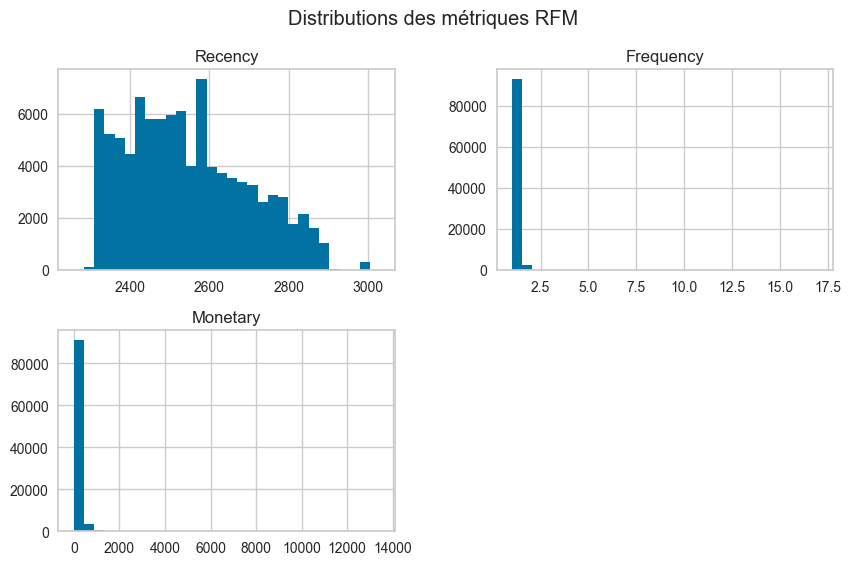

In [60]:
rfm.hist(figsize=(10, 6), bins=30)
plt.suptitle("Distributions des métriques RFM")
plt.show()

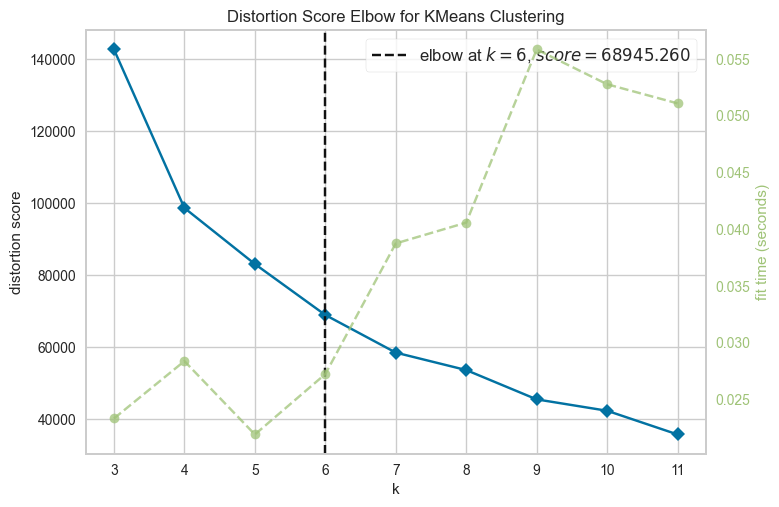

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [61]:
display_info(title="""K-means clustering""",color='red')
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

model = KMeans()

visualizer = KElbowVisualizer(model, k=(3,12))
visualizer.fit(rfm_scaled)
visualizer.show()

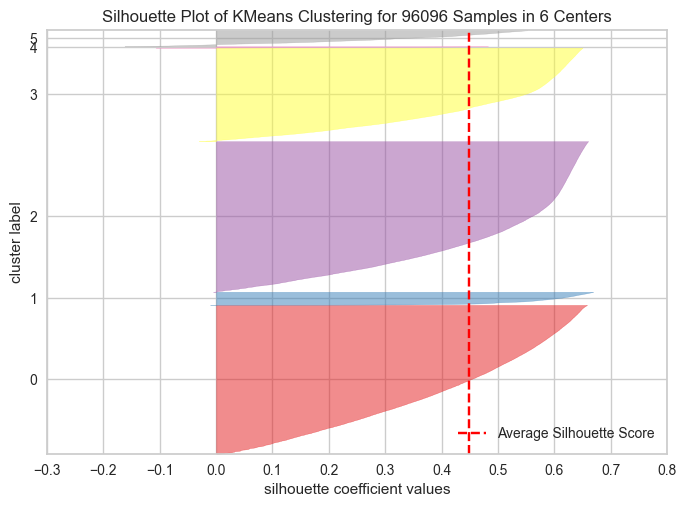

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 96096 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [62]:
model = KMeans(6)
visualizer = SilhouetteVisualizer(model)

visualizer.fit(rfm_scaled)
visualizer.poof()

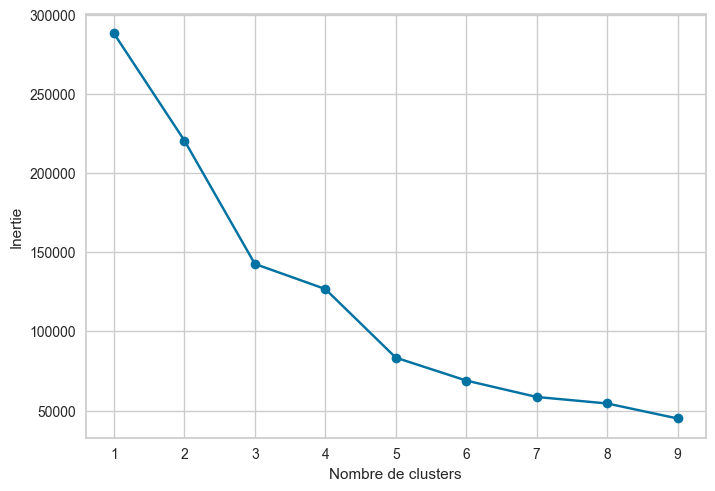

: 

In [24]:
inertias = []
for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(range(1,10), inertias, marker='o')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.show()

In [25]:
display_info(title="""Application du K-means""",color='blue')
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
display(rfm)

,Recency,Frequency,Monetary,Cluster
customer_unique_id,,,,
0000366f3b9a7992bf8c76cfdf3221e2,2419,1,129.90,0
0000b849f77a49e4a4ce2b2a4ca5be3f,2422,1,18.90,0
0000f46a3911fa3c0805444483337064,2844,1,69.00,1
0000f6ccb0745a6a4b88665a16c9f078,2628,1,25.99,2
0004aac84e0df4da2b147fca70cf8255,2595,1,180.00,2
...,...,...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,2754,1,1570.00,1
fffea47cd6d3cc0a88bd621562a9d061,2569,1,64.89,2
ffff371b4d645b6ecea244b27531430a,2875,1,89.90,1


: 

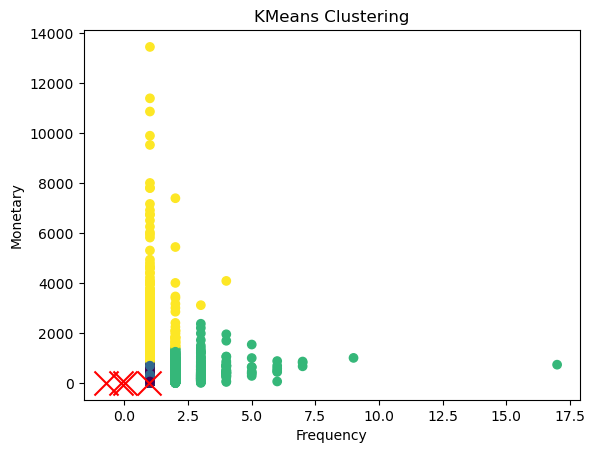

: 

In [21]:
display_info(title="""Affichage de Kmeans clustering""",color='blue')
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='x')
plt.title('KMeans Clustering')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.show()

# pca = PCA(n_components=2)
# data_pca = pca.fit_transform(rfm)

# plt.scatter(data_pca[:, 0], data_pca[:, 1], c=kmeans.labels_, cmap='viridis')
# plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='x')
# plt.title('KMeans Clustering with PCA')
# plt.xlabel('Principal Component 1')
# plt.ylabel('Principal Component 2')
# plt.show()
## TSNE ACP 

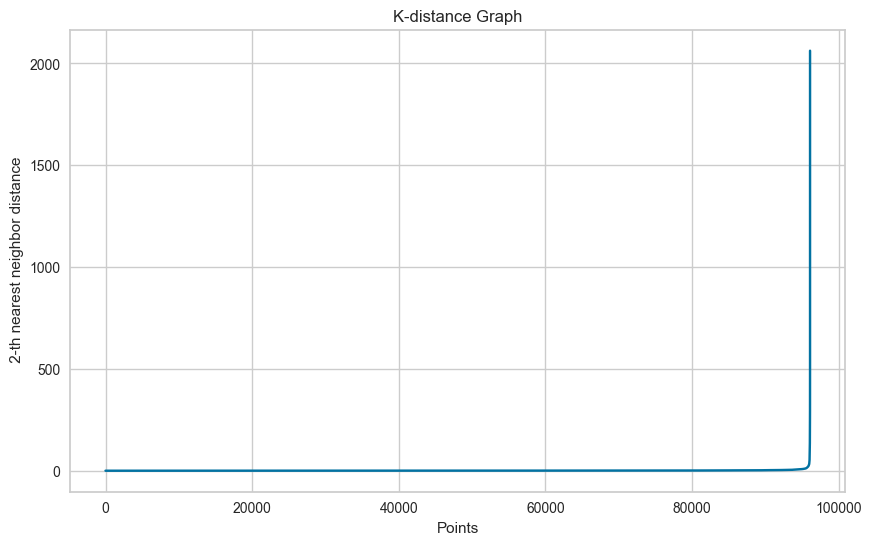

: 

In [40]:
def plot_k_distance_graph (X,k):
        neigh = NearestNeighbors (n_neighbors=k)
        neigh.fit(X)
        distances,_=neigh.kneighbors(X)
        distances = np.sort(distances[:, k-1])
        plt.figure(figsize=(10,6))
        plt.plot(distances)
        plt.xlabel('Points')
        plt.ylabel(f' {k}-th nearest neighbor distance')
        plt.title('K-distance Graph')
        plt.show()
plot_k_distance_graph(rfm, k=2)

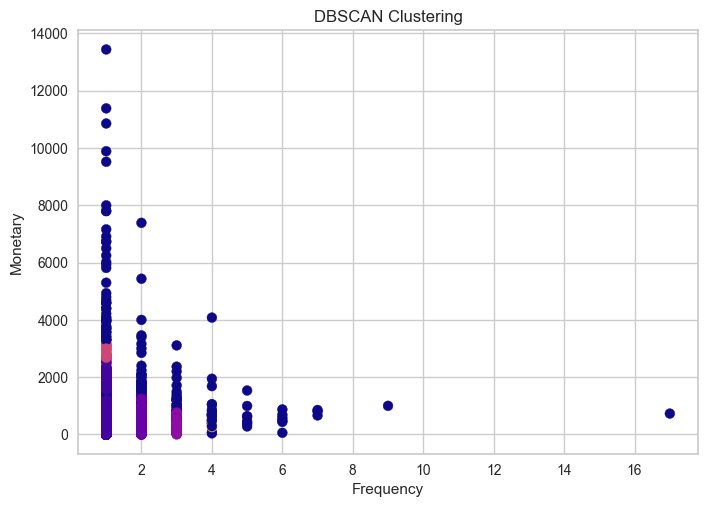

: 

In [26]:
display_info(title="""DBSCAN clustering""",color='red')

dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['DBSCAN_Cluster'] = dbscan.fit_predict(rfm_scaled)

plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['DBSCAN_Cluster'], cmap='plasma', s=50)
plt.title('DBSCAN Clustering')
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.show()

In [42]:
linked= linkage(rfm_scaled, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Clustering Hiérarchique (Dendrogramme)')
plt.xlabel('Points de données')
plt.ylabel('Distance')
plt.show()

: 

: 

In [ ]:
display_info(title="""Hierarchy clustering""",color='red')
rfm['Hierarchical_Cluster'] = fcluster(Z, t=3, criterion='maxclust')


: 